# Téma 8 - Oxford-IIIT Pet objektumszegmentálás Colab kód

Ez a notebook-vázlat Google Colab GPU-ra készült. A cél:

- Oxford-IIIT Pet trimap szegmentáció betöltése
- U-Net, DeepLabV3+ és PSPNet összehasonlítása
- Cross entropy és Dice loss összehasonlítása
- mIoU maximalizálása Colab-kompatibilis futási idő mellett

Colabban: `Runtime -> Change runtime type -> GPU`.

## 1. Telepítés



In [ ]:
!pip -q install segmentation-models-pytorch albumentations==1.4.24 torchmetrics


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 274.9/274.9 kB 12.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 33.0 MB/s eta 0:00:00


## 2. Importok és konfiguráció



In [ ]:
import os
import random
import time
import logging
import warnings
from pathlib import Path

import albumentations as A
import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
from PIL import Image
from torch.utils.data import DataLoader, Dataset
from tqdm.auto import tqdm

import segmentation_models_pytorch as smp

SEED = 42
DATA_DIR = Path("/content/data")
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# "trimap": 3 osztály: pet, border, background
# "binary": 2 osztály: pet vs not-pet; gyorsabb és általában magasabb IoU-t ad
TASK_MODE = "trimap"
NUM_CLASSES = 3 if TASK_MODE == "trimap" else 2

IMAGE_SIZE = 256
BATCH_SIZE = 8
# Colabban a multiprocessing DataLoader gyakran zajos "can only test a child process"
# hibákat ír ki. A num_workers=0 stabilabb és tiszta kimenetet ad.
NUM_WORKERS = 0
EPOCHS = 12
LR = 3e-4
WEIGHT_DECAY = 1e-4

torch.backends.cudnn.benchmark = True
warnings.filterwarnings("ignore", message=".*HF_TOKEN.*")
warnings.filterwarnings("ignore", message=".*unauthenticated requests.*")
logging.getLogger("huggingface_hub").setLevel(logging.ERROR)

def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

seed_everything(SEED)
print("device:", DEVICE)


/usr/local/lib/python3.12/dist-packages/albumentations/__init__.py:24: UserWarning: A new version of Albumentations is available: 2.0.8 (you have 1.4.24). Upgrade using: pip install -U albumentations. To disable automatic update checks, set the environment variable NO_ALBUMENTATIONS_UPDATE to 1.
  check_for_updates()


device: cuda


## 3. Adathalmaz betöltése



In [ ]:
from torchvision.datasets import OxfordIIITPet

# Első futáskor letölti az adatokat.
train_base = OxfordIIITPet(
    root=str(DATA_DIR),
    split="trainval",
    target_types="segmentation",
    download=True,
)
test_base = OxfordIIITPet(
    root=str(DATA_DIR),
    split="test",
    target_types="segmentation",
    download=True,
)

print(len(train_base), len(test_base))


100%|██████████| 792M/792M [00:30<00:00, 25.7MB/s]
100%|██████████| 19.2M/19.2M [00:02<00:00, 9.31MB/s]


3680 3669


## 4. Train/valid split és augmentáció



In [ ]:
indices = np.arange(len(train_base))
np.random.shuffle(indices)
valid_ratio = 0.15
valid_size = int(len(indices) * valid_ratio)
valid_indices = indices[:valid_size]
train_indices = indices[valid_size:]

train_tfms = A.Compose([
    A.Resize(IMAGE_SIZE, IMAGE_SIZE),
    A.HorizontalFlip(p=0.5),
    A.ShiftScaleRotate(
        shift_limit=0.05,
        scale_limit=0.15,
        rotate_limit=20,
        border_mode=cv2.BORDER_REFLECT_101,
        p=0.7,
    ),
    A.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.15, hue=0.03, p=0.5),
    A.GaussNoise(var_limit=(5.0, 25.0), p=0.2),
])

eval_tfms = A.Compose([
    A.Resize(IMAGE_SIZE, IMAGE_SIZE),
])

class PetSegDataset(Dataset):
    def __init__(self, base_dataset, indices, transforms=None, task_mode="trimap"):
        self.base = base_dataset
        self.indices = list(indices)
        self.transforms = transforms
        self.task_mode = task_mode

    def __len__(self):
        return len(self.indices)

    def _convert_mask(self, mask):
        # Oxford trimap értékek: 1=pet, 2=border, 3=background.
        mask = np.array(mask, dtype=np.uint8)
        if self.task_mode == "trimap":
            # 0=pet, 1=border, 2=background
            mask = mask - 1
        else:
            # 0=background/border, 1=pet
            mask = (mask == 1).astype(np.uint8)
        return mask

    def __getitem__(self, i):
        img, mask = self.base[self.indices[i]]
        img = np.array(img.convert("RGB"))
        mask = self._convert_mask(mask)

        if self.transforms is not None:
            out = self.transforms(image=img, mask=mask)
            img, mask = out["image"], out["mask"]

        img = img.astype(np.float32) / 255.0
        img = np.transpose(img, (2, 0, 1))
        mask = mask.astype(np.int64)
        return torch.tensor(img), torch.tensor(mask)

train_ds = PetSegDataset(train_base, train_indices, train_tfms, TASK_MODE)
valid_ds = PetSegDataset(train_base, valid_indices, eval_tfms, TASK_MODE)
test_ds = PetSegDataset(test_base, np.arange(len(test_base)), eval_tfms, TASK_MODE)

train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=(DEVICE == "cuda"),
)
valid_loader = DataLoader(
    valid_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=(DEVICE == "cuda"),
)
test_loader = DataLoader(
    test_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=(DEVICE == "cuda"),
)

print(len(train_ds), len(valid_ds), len(test_ds))


3128 552 3669


## 5. Vizualizáció ellenőrzéshez



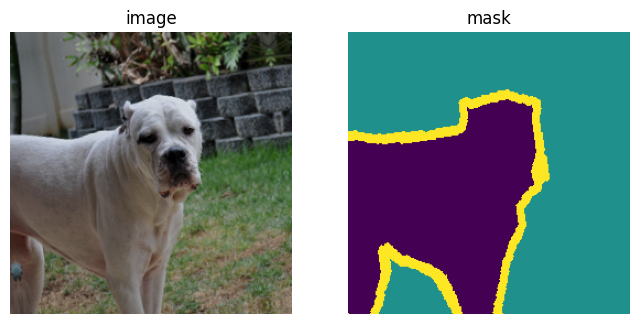

In [ ]:
def show_sample(dataset, idx=0):
    img, mask = dataset[idx]
    img_np = img.permute(1, 2, 0).numpy()
    plt.figure(figsize=(8, 4))
    plt.subplot(1, 2, 1)
    plt.imshow(img_np)
    plt.axis("off")
    plt.title("image")
    plt.subplot(1, 2, 2)
    plt.imshow(mask.numpy(), cmap="viridis", vmin=0, vmax=NUM_CLASSES-1)
    plt.axis("off")
    plt.title("mask")
    plt.show()

show_sample(train_ds, 0)


## 6. Loss függvények



In [ ]:
class SoftDiceLoss(nn.Module):
    def __init__(self, num_classes, smooth=1.0):
        super().__init__()
        self.num_classes = num_classes
        self.smooth = smooth

    def forward(self, logits, target):
        probs = torch.softmax(logits, dim=1)
        target_1h = F.one_hot(target, num_classes=self.num_classes).permute(0, 3, 1, 2).float()
        dims = (0, 2, 3)
        intersection = torch.sum(probs * target_1h, dims)
        cardinality = torch.sum(probs + target_1h, dims)
        dice = (2.0 * intersection + self.smooth) / (cardinality + self.smooth)
        return 1.0 - dice.mean()

def build_loss(loss_name):
    if loss_name == "ce":
        return nn.CrossEntropyLoss()
    if loss_name == "dice":
        return SoftDiceLoss(NUM_CLASSES)
    raise ValueError(loss_name)


## 7. mIoU metrika



In [ ]:
@torch.no_grad()
def confusion_matrix(pred, target, num_classes):
    pred = pred.view(-1)
    target = target.view(-1)
    valid = (target >= 0) & (target < num_classes)
    hist = torch.bincount(
        num_classes * target[valid] + pred[valid],
        minlength=num_classes ** 2,
    ).reshape(num_classes, num_classes)
    return hist

def miou_from_hist(hist):
    hist = hist.float()
    intersection = torch.diag(hist)
    union = hist.sum(1) + hist.sum(0) - intersection
    iou = intersection / union.clamp(min=1)
    return iou.mean().item(), iou.cpu().numpy()


## 8. Modellek



In [ ]:
def create_model(arch):
    common = dict(
        encoder_name="resnet34",
        encoder_weights="imagenet",
        in_channels=3,
        classes=NUM_CLASSES,
    )
    if arch == "unet":
        return smp.Unet(**common)
    if arch == "deeplabv3plus":
        return smp.DeepLabV3Plus(**common)
    if arch == "pspnet":
        return smp.PSPNet(**common)
    raise ValueError(arch)


## 9. Tanítás és kiértékelés



In [ ]:
def train_one_epoch(model, loader, criterion, optimizer, scaler):
    model.train()
    running_loss = 0.0
    for imgs, masks in tqdm(loader, leave=False):
        imgs = imgs.to(DEVICE, non_blocking=True)
        masks = masks.to(DEVICE, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)
        with torch.amp.autocast("cuda", enabled=(DEVICE == "cuda")):
            logits = model(imgs)
            loss = criterion(logits, masks)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        running_loss += loss.item() * imgs.size(0)

    return running_loss / len(loader.dataset)

@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    running_loss = 0.0
    hist = torch.zeros(NUM_CLASSES, NUM_CLASSES, device=DEVICE)

    for imgs, masks in tqdm(loader, leave=False):
        imgs = imgs.to(DEVICE, non_blocking=True)
        masks = masks.to(DEVICE, non_blocking=True)
        logits = model(imgs)
        loss = criterion(logits, masks)
        pred = logits.argmax(dim=1)

        running_loss += loss.item() * imgs.size(0)
        hist += confusion_matrix(pred, masks, NUM_CLASSES)

    miou, class_iou = miou_from_hist(hist)
    return running_loss / len(loader.dataset), miou, class_iou

def run_experiment(arch, loss_name, epochs=EPOCHS):
    seed_everything(SEED)
    model = create_model(arch).to(DEVICE)
    criterion = build_loss(loss_name)
    optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    scaler = torch.amp.GradScaler("cuda", enabled=(DEVICE == "cuda"))

    best_miou = -1
    best_path = f"/content/best_{arch}_{loss_name}_{TASK_MODE}.pt"
    history = []
    start = time.time()

    for epoch in range(1, epochs + 1):
        train_loss = train_one_epoch(model, train_loader, criterion, optimizer, scaler)
        valid_loss, valid_miou, valid_class_iou = evaluate(model, valid_loader, criterion)
        scheduler.step()

        row = {
            "arch": arch,
            "loss": loss_name,
            "epoch": epoch,
            "train_loss": train_loss,
            "valid_loss": valid_loss,
            "valid_miou": valid_miou,
            "lr": scheduler.get_last_lr()[0],
        }
        history.append(row)
        print(row)
        print("class IoU:", np.round(valid_class_iou, 4))

        if valid_miou > best_miou:
            best_miou = valid_miou
            torch.save(model.state_dict(), best_path)

    elapsed_min = (time.time() - start) / 60
    model.load_state_dict(torch.load(best_path, map_location=DEVICE))
    test_loss, test_miou, test_class_iou = evaluate(model, test_loader, criterion)

    result = {
        "arch": arch,
        "loss": loss_name,
        "best_valid_miou": best_miou,
        "test_miou": test_miou,
        "test_loss": test_loss,
        "minutes": elapsed_min,
        "best_path": best_path,
        "class_iou": test_class_iou,
    }
    return result, pd.DataFrame(history), model


## 10. Kísérletek futtatása

Ha kevés az idő, először csak `unet + ce` és `unet + dice` fusson. A teljes összehasonlítás 6 futás.



In [ ]:
experiments = [
    ("unet", "ce"),
    ("unet", "dice"),
    ("deeplabv3plus", "ce"),
    ("deeplabv3plus", "dice"),
    ("pspnet", "ce"),
    ("pspnet", "dice"),
]

all_results = []
all_histories = []
last_model = None

for arch, loss_name in experiments:
    print(f"\n=== {arch} / {loss_name} ===")
    result, hist_df, last_model = run_experiment(arch, loss_name, epochs=EPOCHS)
    all_results.append(result)
    all_histories.append(hist_df)

results_df = pd.DataFrame([
    {k: v for k, v in r.items() if k != "class_iou"}
    for r in all_results
]).sort_values("test_miou", ascending=False)

history_df = pd.concat(all_histories, ignore_index=True)

display(results_df)
results_df.to_csv("/content/results_summary.csv", index=False)
history_df.to_csv("/content/training_history.csv", index=False)



=== unet / ce ===


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/87.3M [00:00<?, ?B/s]

  0%|          | 0/391 [00:00<?, ?it/s]

...

  0%|          | 0/391 [00:00<?, ?it/s]

  0%|          | 0/69 [00:00<?, ?it/s]

{'arch': 'pspnet', 'loss': 'dice', 'epoch': 12, 'train_loss': 0.16283797790937107, 'valid_loss': 0.1426611076230588, 'valid_miou': 0.7705255746841431, 'lr': 0.0}
class IoU: [0.8528 0.9195 0.5393]


  0%|          | 0/459 [00:00<?, ?it/s]

,arch,loss,best_valid_miou,test_miou,test_loss,minutes,best_path
1,unet,dice,0.796164,0.804125,0.117681,11.142798,/content/best_unet_dice_trimap.pt
3,deeplabv3plus,dice,0.795949,0.801990,0.120157,9.817838,/content/best_deeplabv3plus_dice_trimap.pt
0,unet,ce,0.796141,0.801503,0.179084,11.504761,/content/best_unet_ce_trimap.pt
2,deeplabv3plus,ce,0.792029,0.793451,0.186960,9.748816,/content/best_deeplabv3plus_ce_trimap.pt
5,pspnet,dice,0.770526,0.780263,0.135263,8.315298,/content/best_pspnet_dice_trimap.pt
4,pspnet,ce,0.764299,0.767780,0.219737,8.186530,/content/best_pspnet_ce_trimap.pt


## 11. Eredmények ábrázolása



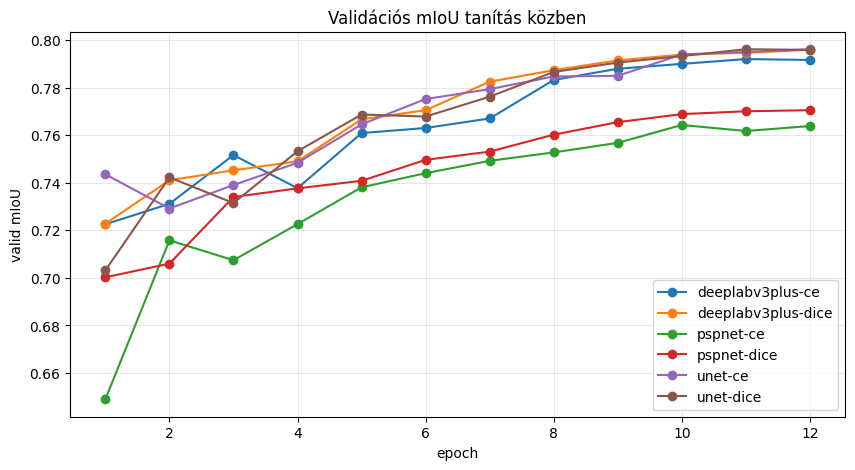

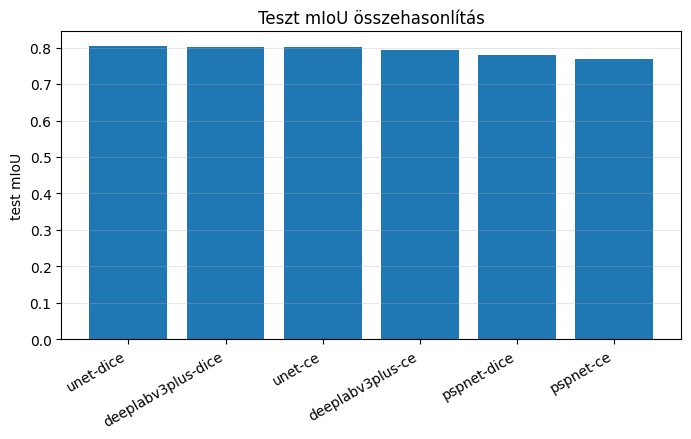

In [ ]:
plt.figure(figsize=(10, 5))
for (arch, loss_name), group in history_df.groupby(["arch", "loss"]):
    plt.plot(group["epoch"], group["valid_miou"], marker="o", label=f"{arch}-{loss_name}")
plt.xlabel("epoch")
plt.ylabel("valid mIoU")
plt.grid(True, alpha=0.3)
plt.legend()
plt.title("Validációs mIoU tanítás közben")
plt.show()

plt.figure(figsize=(8, 4))
labels = results_df["arch"] + "-" + results_df["loss"]
plt.bar(labels, results_df["test_miou"])
plt.xticks(rotation=30, ha="right")
plt.ylabel("test mIoU")
plt.title("Teszt mIoU összehasonlítás")
plt.grid(axis="y", alpha=0.3)
plt.show()


## 12. Predikciók vizualizálása



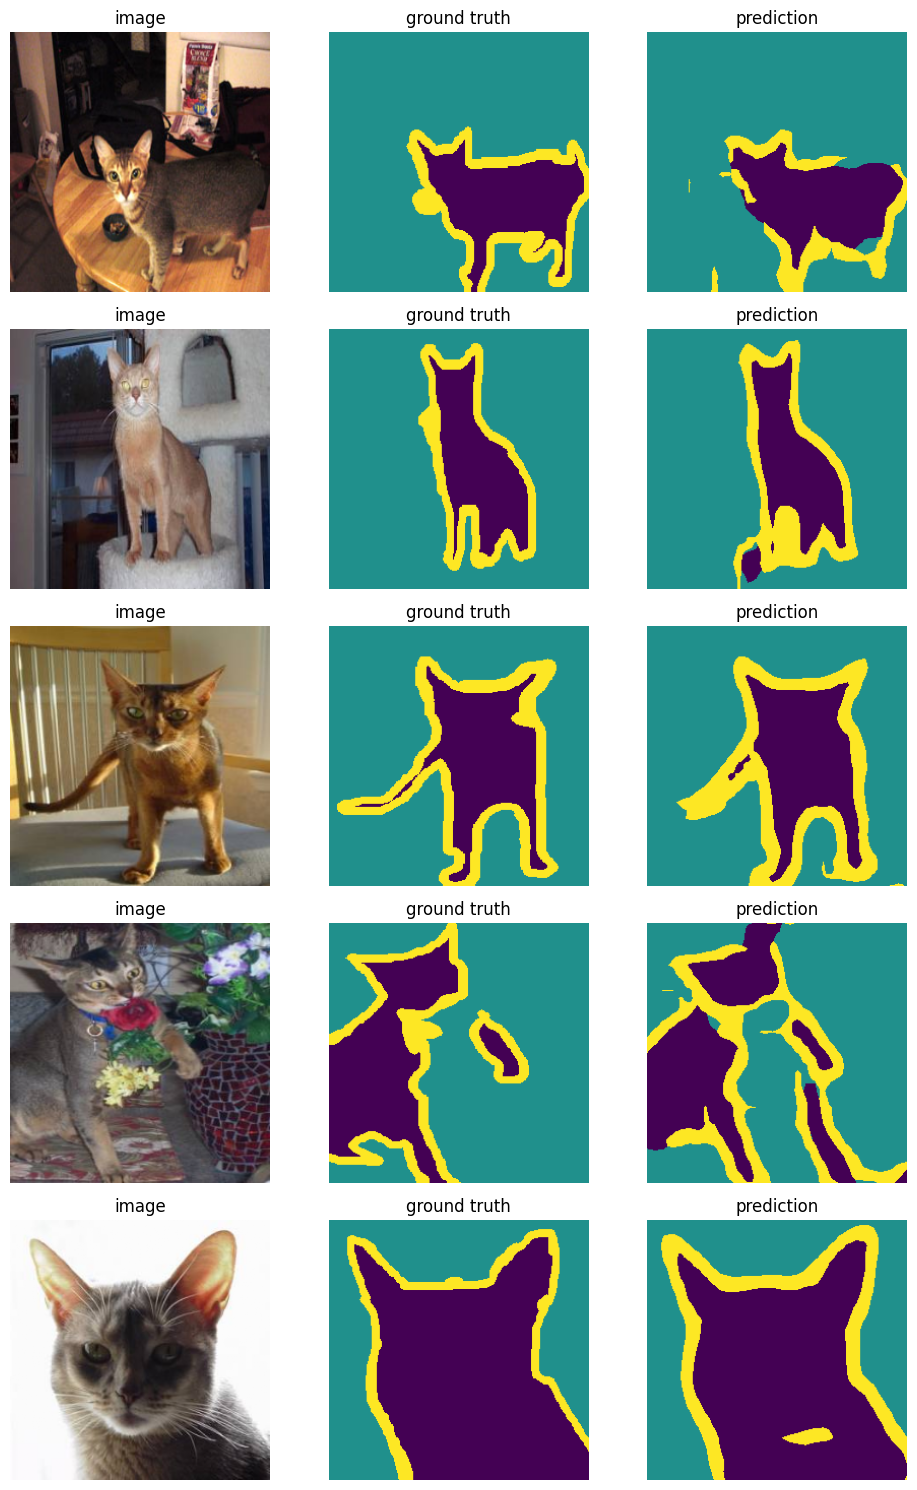

In [ ]:
def visualize_predictions(model, dataset, n=4):
    model.eval()
    plt.figure(figsize=(10, 3 * n))
    for i in range(n):
        img, mask = dataset[i]
        with torch.no_grad():
            logits = model(img.unsqueeze(0).to(DEVICE))
            pred = logits.argmax(1).squeeze(0).cpu()

        plt.subplot(n, 3, 3*i + 1)
        plt.imshow(img.permute(1, 2, 0).numpy())
        plt.axis("off")
        plt.title("image")

        plt.subplot(n, 3, 3*i + 2)
        plt.imshow(mask.numpy(), cmap="viridis", vmin=0, vmax=NUM_CLASSES-1)
        plt.axis("off")
        plt.title("ground truth")

        plt.subplot(n, 3, 3*i + 3)
        plt.imshow(pred.numpy(), cmap="viridis", vmin=0, vmax=NUM_CLASSES-1)
        plt.axis("off")
        plt.title("prediction")
    plt.tight_layout()
    plt.show()

# A legutóbb tanított modellhez:
visualize_predictions(last_model, test_ds, n=5)


In [ ]:
!zip /content/trained_models.zip /content/best_*.pt
from google.colab import files
files.download("/content/trained_models.zip")

  adding: content/best_deeplabv3plus_ce_trimap.pt (deflated 7%)
  adding: content/best_deeplabv3plus_dice_trimap.pt (deflated 7%)
  adding: content/best_pspnet_ce_trimap.pt (deflated 7%)
  adding: content/best_pspnet_dice_trimap.pt (deflated 7%)
  adding: content/best_unet_ce_trimap.pt (deflated 7%)
  adding: content/best_unet_dice_trimap.pt (deflated 7%)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 13. mIoU maximalizálási javaslatok Colab GPU-ra

Ezeket külön kísérletként érdemes futtatni, nem egyszerre:



In [ ]:
# 1. Nagyobb felbontás:
IMAGE_SIZE = 320
BATCH_SIZE = 4

# 2. Több epoch:
EPOCHS = 20

# 3. Erősebb encoder, ha belefér memóriába:
# create_model() common részében:
# encoder_name="efficientnet-b3"

# 4. Kombinált loss, opcionális extra:
# loss = 0.5 * CrossEntropy + 0.5 * Dice


## 14. Hivatkozások

- Ronneberger, Fischer, Brox: U-Net: Convolutional Networks for Biomedical Image Segmentation, 2015.
- Oxford-IIIT Pet Dataset: Parkhi et al., Cats and Dogs, CVPR 2012.
- `segmentation_models_pytorch`: előtanított encoderek és szegmentációs architektúrák gyors kísérletezéshez.
